# Assignment 2: Part 2
Hallee Pham  
The report with a full explanations can be found `https://github.com/halleepham/DataScience-Assignment2/tree/main/Part2/report/part2_report.pdf`

## Setup
* Imports
* Read data

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Read data
diabetes_population = pd.read_csv('https://raw.githubusercontent.com/halleepham/DataScience-Assignment2/refs/heads/main/Part2/data/diabetes.csv')
print(f'Number of observations in population: {len(diabetes_population)}')
diabetes_population.head()

Number of observations in population: 768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Part A
* Set seed for reproducibility
* Take random sample of 25 observations
* Find summary stats of sample and population
* Compare using charts

In [2]:
# Take random sample of 25
diabetes_sample = diabetes_population.sample(n=25, random_state=42)
diabetes_sample

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0
204,6,103,72,32,190,37.7,0.324,55,0
97,1,71,48,18,76,20.4,0.323,22,0
336,0,117,0,0,0,33.8,0.932,44,0
568,4,154,72,29,126,31.3,0.338,37,0
148,5,147,78,0,0,33.7,0.218,65,0


In [3]:
# Mean and max of sample
sample_mean = diabetes_sample['Glucose'].mean()
sample_max = diabetes_sample['Glucose'].max()

# Mean and max of population
pop_mean = diabetes_population['Glucose'].mean()
pop_max = diabetes_population['Glucose'].max()

print(f'Sample mean: {sample_mean}')
print(f'Sample max: {sample_max}')
print(f'\nPopulation mean: {pop_mean:.2f}')
print(f'Population max: {pop_max}')

Sample mean: 116.64
Sample max: 183

Population mean: 120.89
Population max: 199


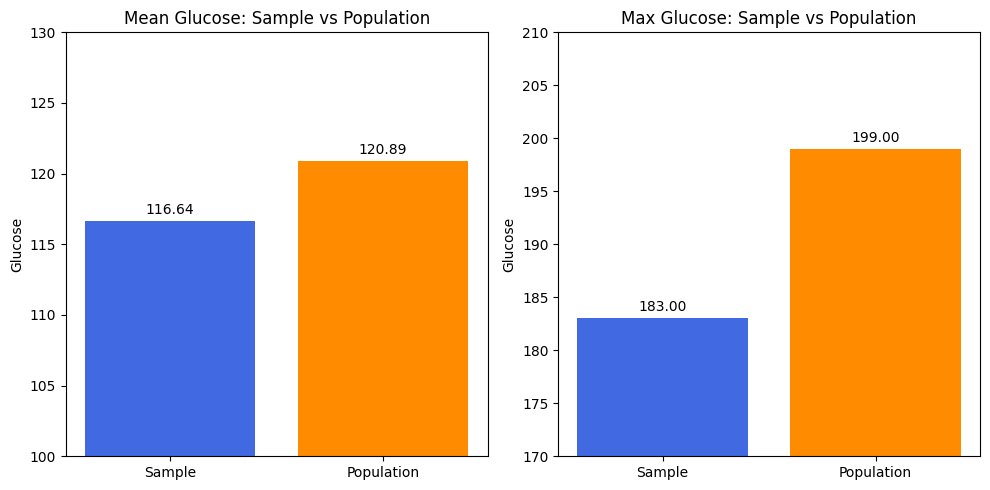

In [4]:
# Bar chart comparing sample and population
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Mean comparison subplot
axes[0].bar(['Sample', 'Population'], [sample_mean, pop_mean], color=['royalblue', 'darkorange'])
axes[0].bar_label(axes[0].containers[0], fmt='%.2f', padding=3)
axes[0].set_title('Mean Glucose: Sample vs Population')
axes[0].set_ylabel('Glucose')
axes[0].set_ylim(100, 130)

# Max comparison subplot
axes[1].bar(['Sample', 'Population'], [sample_max, pop_max], color=['royalblue', 'darkorange'])
axes[1].bar_label(axes[1].containers[0], fmt='%.2f', padding=3)
axes[1].set_title('Max Glucose: Sample vs Population')
axes[1].set_ylabel('Glucose')
axes[1].set_ylim(170, 210)

plt.tight_layout()
plt.savefig('partA_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

Observations:
* It can be seen that the sample mean is smaller than the population
* Sample max is much smaller than population max

/tmp/ipykernel_68256/1813396490.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([diabetes_population['Glucose'], diabetes_sample['Glucose']], labels=['Population', 'Sample'])


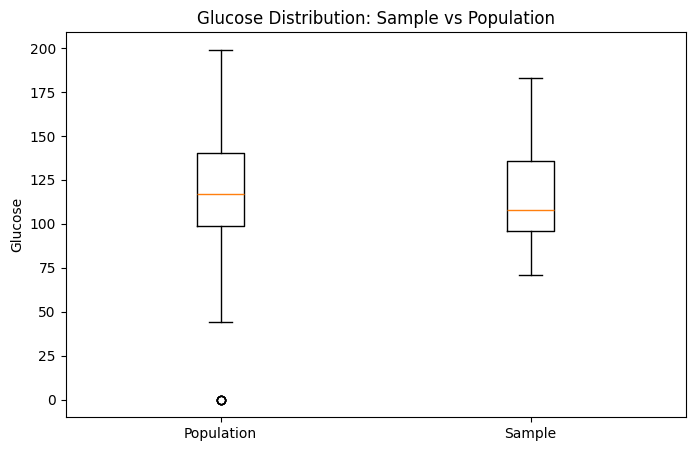

In [5]:
plt.figure(figsize=(8, 5))
plt.boxplot([diabetes_population['Glucose'], diabetes_sample['Glucose']], labels=['Population', 'Sample'])
plt.title('Glucose Distribution: Sample vs Population')
plt.ylabel('Glucose')

plt.savefig('partA_boxwhisker.png', dpi=300, bbox_inches='tight')
plt.show()

Observations:
* The population has a much larger range, with one extreme low outlier
* the random sample happened to capture the spread of the population well (seen by the size of the IQR)

## Part B
* Find 98th percentile of sample and population and compare

In [6]:
# 98th percentile of sample
sample_98th = np.percentile(diabetes_sample['BMI'], 98)

# 98th percentile of population
pop_98th = np.percentile(diabetes_population['BMI'], 98)

print(f'Sample 98th percentile: {sample_98th:.2f}')
print(f'Population 98th percentile: {pop_98th:.2f}')

Sample 98th percentile: 40.25
Population 98th percentile: 47.53


Observations:
* 98% of patients in the SAMPLE have a BMI value equal or below 40.25
* 98% of patients in the POPULATION have a BMI value equal or below 47.53
* the sample underestimates the 98th percentile by about 7 points

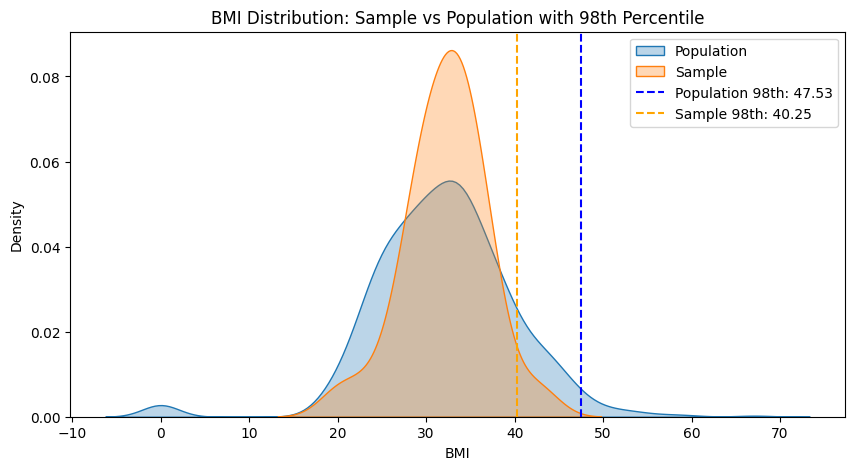

In [7]:
plt.figure(figsize=(10, 5))

sns.kdeplot(diabetes_population['BMI'], label='Population', fill=True, alpha=0.3)
sns.kdeplot(diabetes_sample['BMI'], label='Sample', fill=True, alpha=0.3)

plt.axvline(pop_98th, color='blue', linestyle='--', label=f'Population 98th: {pop_98th:.2f}')
plt.axvline(sample_98th, color='orange', linestyle='--', label=f'Sample 98th: {sample_98th:.2f}')

plt.title('BMI Distribution: Sample vs Population with 98th Percentile')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.legend()

plt.savefig('partB_KDE.png', dpi=300, bbox_inches='tight')
plt.show()

Observations:
* A random sample of size 25 may have not been a big enough to capture the higher end of the distribution for BMI
* It can bee seen in the chart above and from the previous box-and-whisker plot that the sample did not capture the range of higher values that are in the population
* The small sample did a reasonable job at estimating mean and median, but this sample size doesn't estimate "tail statistics" well.

## Part C
* Bootstrap 500 samples
* Calculate stats for BloodPressure

In [8]:
sample_means = []
sample_stds = []
sample_percentiles = []

# Create bootstrap samples and collect stats across samples
for i in range(500):
  sample = diabetes_population['BloodPressure'].sample(n=150, replace=True, random_state=i)
  sample_means.append(sample.mean())
  sample_stds.append(sample.std())
  sample_percentiles.append(np.percentile(sample, 98))

# Calculate averages
avg_mean = np.mean(sample_means)
avg_std = np.mean(sample_stds)
avg_percentile = np.mean(sample_percentiles)

# Population stats
pop_mean_bp = diabetes_population['BloodPressure'].mean()
pop_std_bp = diabetes_population['BloodPressure'].std()
pop_percentile_bp = np.percentile(diabetes_population['BloodPressure'], 98)

print(f"Bootstrap avg mean: {avg_mean:.2f} | Population mean: {pop_mean_bp:.2f}")
print(f"Bootstrap avg std: {avg_std:.2f} | Population std: {pop_std_bp:.2f}")
print(f"Bootstrap avg 98th percentile: {avg_percentile:.2f} | Population 98th percentile: {pop_percentile_bp:.2f}")


Bootstrap avg mean: 69.17 | Population mean: 69.11
Bootstrap avg std: 19.20 | Population std: 19.36
Bootstrap avg 98th percentile: 98.31 | Population 98th percentile: 99.32


Observations:
* The mean is almost identical
* The standard deviation is also very close
* The 98th percentile is close, but the sample underestimates it by a little.

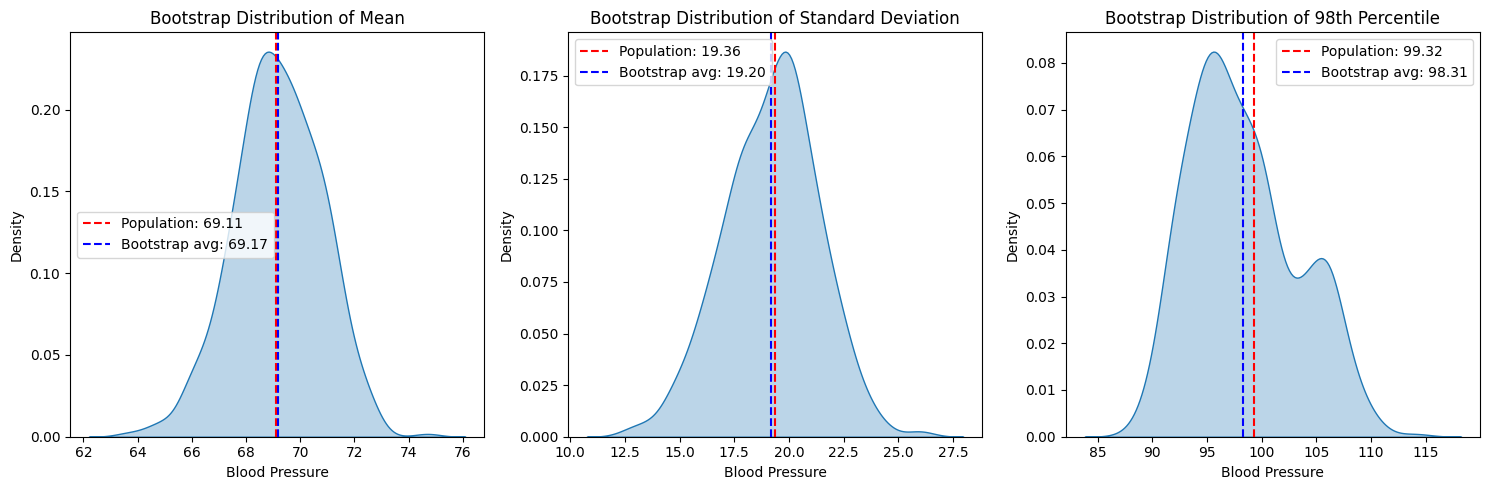

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mean
sns.kdeplot(sample_means, ax=axes[0], fill=True, alpha=0.3)
axes[0].axvline(pop_mean_bp, color='red', linestyle='--', label=f'Population: {pop_mean_bp:.2f}')
axes[0].axvline(avg_mean, color='blue', linestyle='--', label=f'Bootstrap avg: {avg_mean:.2f}')
axes[0].set_title('Bootstrap Distribution of Mean')
axes[0].set_xlabel('Blood Pressure')
axes[0].legend()

# Standard Deviation
sns.kdeplot(sample_stds, ax=axes[1], fill=True, alpha=0.3)
axes[1].axvline(pop_std_bp, color='red', linestyle='--', label=f'Population: {pop_std_bp:.2f}')
axes[1].axvline(avg_std, color='blue', linestyle='--', label=f'Bootstrap avg: {avg_std:.2f}')
axes[1].set_title('Bootstrap Distribution of Standard Deviation')
axes[1].set_xlabel('Blood Pressure')
axes[1].legend()

# 98th Percentile
sns.kdeplot(sample_percentiles, ax=axes[2], fill=True, alpha=0.3)
axes[2].axvline(pop_percentile_bp, color='red', linestyle='--', label=f'Population: {pop_percentile_bp:.2f}')
axes[2].axvline(avg_percentile, color='blue', linestyle='--', label=f'Bootstrap avg: {avg_percentile:.2f}')
axes[2].set_title('Bootstrap Distribution of 98th Percentile')
axes[2].set_xlabel('Blood Pressure')
axes[2].legend()

plt.tight_layout()
plt.savefig('partC_KDE.png', dpi=300, bbox_inches='tight')
plt.show()